# CML Session 9 — K-Nearest Neighbours (k-NN) — Full Teaching Notebook

Undergrad-friendly deep dive: algorithm, distances, choosing **k**, and the curse of dimensionality.

**You will**
1. Walk the classify / regress algorithm on a query point
2. Compare Euclidean vs Manhattan and see why scaling matters
3. Watch decision boundaries change with k (bias–variance)
4. Plot distance concentration as dimension grows

Companion notes: `notes_elaborate.md` (Unicode math, Google Docs–friendly).

Figures are embedded below; re-run code cells to regenerate them into `assets/`.


## 0. Setup

Works in Colab or locally with `numpy`, `matplotlib`, and `scikit-learn`.

**Colab tip:** Run the setup cell, then the *Regenerate all teaching figures* cell, before any `show_png` cells (or use **Runtime → Run all** — order is already correct).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image, display

from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

np.random.seed(42)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 12,
})

# Prefer assets next to this project; fall back to cwd (Colab)
_CANDIDATES = [
    Path("/workspace/cml_sessions/s9_knn/assets"),
    Path.cwd() / "assets",
    Path("/content") / "assets",
]
ASSETS = next((p for p in _CANDIDATES if p.exists()), Path.cwd() / "assets")
ASSETS.mkdir(parents=True, exist_ok=True)

def show_png(name, width=720):
    path = ASSETS / name
    if not path.exists():
        for root in [ASSETS.parent, Path.cwd(), Path("/content"), Path("/workspace/cml_sessions/s9_knn")]:
            alt = root / "assets" / name
            if alt.exists():
                path = alt
                break
    if path.exists():
        display(Image(filename=str(path.resolve()), width=width))
    else:
        print(f"Missing {path.name}. Run the Regenerate figures section first, then re-run this cell.")

print("Ready. ASSETS =", ASSETS.resolve())


Ready. ASSETS = /content/assets


## 0b. Regenerate all teaching figures (run first)

Creates the five PNGs under `ASSETS` so every later `show_png(...)` cell finds them — including Colab **Run all**.


In [2]:
# --- Regenerate all teaching figures into ASSETS ---
# 1) knn_classify_steps
np.random.seed(7)
fig, ax = plt.subplots(figsize=(8, 6.5))
A = np.array([[1.0, 2.2], [1.5, 1.8], [0.8, 1.5], [2.0, 2.5], [1.2, 2.8],
              [0.5, 2.0], [1.8, 1.2], [2.2, 1.9], [0.9, 2.5]])
B = np.array([[3.5, 3.0], [4.0, 2.5], [3.2, 2.2], [3.8, 3.5], [4.2, 3.2],
              [3.0, 3.5], [4.5, 2.8], [3.6, 1.8], [4.0, 1.5]])
ax.scatter(A[:,0], A[:,1], c="#1f77b4", s=90, label="Class A (train)", zorder=3, edgecolors="k", linewidths=0.5)
ax.scatter(B[:,0], B[:,1], c="#ff7f0e", s=90, label="Class B (train)", zorder=3, edgecolors="k", linewidths=0.5)
query = np.array([2.5, 2.4])
ax.scatter([query[0]], [query[1]], c="red", s=200, marker="*", label="Query x*", zorder=5, edgecolors="k")
all_pts = np.vstack([A, B])
labels = np.array([0]*len(A) + [1]*len(B))
dists = np.linalg.norm(all_pts - query, axis=1)
idx = np.argsort(dists)[:5]
for i in idx:
    ax.plot([query[0], all_pts[i,0]], [query[1], all_pts[i,1]], "k--", alpha=0.55, lw=1.5, zorder=2)
    ax.add_patch(plt.Circle(all_pts[i], 0.18, fill=False, ec="green", lw=2.2, zorder=4))
nA = int((labels[idx]==0).sum()); nB = int((labels[idx]==1).sum())
pred_label = "A" if nA > nB else "B"
ax.text(0.02, 0.98, f"k = 5\nVote: A={nA}, B={nB} → predict {pred_label}",
        transform=ax.transAxes, va="top",
        bbox=dict(boxstyle="round", facecolor="#e8f5e9", edgecolor="green"))
ax.set_title("k-NN classification steps"); ax.legend(loc="lower right"); ax.grid(True, alpha=0.3)
ax.set_aspect("equal", adjustable="box"); fig.tight_layout()
fig.savefig(ASSETS / "knn_classify_steps.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.close(fig)

# 2) euclidean_vs_manhattan
fig, ax = plt.subplots(figsize=(7.5, 6.5))
p1, p2 = np.array([1.0, 1.0]), np.array([4.0, 3.5])
ax.scatter([p1[0]], [p1[1]], c="#1f77b4", s=160, zorder=5, edgecolors="k", label="Point x")
ax.scatter([p2[0]], [p2[1]], c="#d62728", s=160, zorder=5, edgecolors="k", label="Point z")
ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color="#2ca02c", lw=3, label="Euclidean")
corner = np.array([p2[0], p1[1]])
ax.plot([p1[0], corner[0], p2[0]], [p1[1], corner[1], p2[1]], color="#9467bd", lw=3, ls="--", label="Manhattan")
eu, man = np.linalg.norm(p2-p1), np.abs(p2-p1).sum()
ax.text(0.02, 0.98, f"d₂ ≈ {eu:.2f}\nd₁ = {man:.2f}", transform=ax.transAxes, va="top",
        bbox=dict(boxstyle="round", facecolor="#fff8e1", edgecolor="#f9a825"))
ax.set_title("Euclidean vs Manhattan"); ax.legend(loc="lower right"); ax.grid(True, alpha=0.3)
ax.set_aspect("equal", adjustable="box"); fig.tight_layout()
fig.savefig(ASSETS / "euclidean_vs_manhattan.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.close(fig)

# 3) scaling_matters
train = np.array([[25, 80000], [40, 42000], [38, 41000], [55, 45000], [28, 75000]])
q = np.array([30.0, 43000.0])
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
ax.scatter(train[:,0], train[:,1]/1000, c="#1f77b4", s=100, edgecolors="k")
ax.scatter([q[0]], [q[1]/1000], c="red", s=220, marker="*", edgecolors="k")
nn = np.argsort(np.linalg.norm(train - q, axis=1))[:2]
for i in nn:
    ax.plot([q[0], train[i,0]], [q[1]/1000, train[i,1]/1000], "g--", lw=2)
ax.set_title("BEFORE scaling"); ax.set_xlabel("Age"); ax.set_ylabel("Income (k)")
mu, sd = train.mean(0), train.std(0)
ts, qs = (train-mu)/sd, (q-mu)/sd
ax = axes[1]
ax.scatter(ts[:,0], ts[:,1], c="#1f77b4", s=100, edgecolors="k")
ax.scatter([qs[0]], [qs[1]], c="red", s=220, marker="*", edgecolors="k")
nn = np.argsort(np.linalg.norm(ts - qs, axis=1))[:2]
for i in nn:
    ax.plot([qs[0], ts[i,0]], [qs[1], ts[i,1]], "g--", lw=2)
ax.set_title("AFTER scaling"); ax.set_xlabel("Age (z)"); ax.set_ylabel("Income (z)")
fig.suptitle("Why feature scaling matters for k-NN")
fig.tight_layout()
fig.savefig(ASSETS / "scaling_matters.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.close(fig)

# 4) k_bias_variance_boundaries
X_fig, y_fig = make_classification(
    n_samples=220, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=1.0, random_state=42,
)
X_fig = StandardScaler().fit_transform(X_fig)
ks = [1, 5, 25]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
xx, yy = np.meshgrid(
    np.linspace(X_fig[:, 0].min() - 0.5, X_fig[:, 0].max() + 0.5, 300),
    np.linspace(X_fig[:, 1].min() - 0.5, X_fig[:, 1].max() + 0.5, 300),
)
grid = np.c_[xx.ravel(), yy.ravel()]
titles = [
    "k=1 (low bias, high variance)",
    "k=5 (balanced)",
    "k=25 (higher bias, lower variance)",
]
for ax, k, title in zip(axes, ks, titles):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_fig, y_fig)
    Z = clf.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap="coolwarm", levels=1)
    ax.scatter(X_fig[y_fig == 0, 0], X_fig[y_fig == 0, 1], c="#1f77b4", s=22, edgecolors="k", linewidths=0.25)
    ax.scatter(X_fig[y_fig == 1, 0], X_fig[y_fig == 1, 1], c="#d62728", s=22, edgecolors="k", linewidths=0.25)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Effect of k on decision boundary")
fig.tight_layout()
fig.savefig(ASSETS / "k_bias_variance_boundaries.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.close(fig)

# 5) curse_concentration
rng = np.random.default_rng(0)
dims = list(range(1, 51))
ratios = []
n_pts = 500
for d in dims:
    data = rng.random((n_pts, d))
    qpt = rng.random(d)
    dists = np.linalg.norm(data - qpt, axis=1)
    ratios.append((dists.max() - dists.min()) / dists.mean())
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(dims, ratios, lw=2.5)
ax.set_xlabel("Dimension d")
ax.set_ylabel("(max − min) / mean distance")
ax.set_title("Distance concentration as dimension grows")
ax.grid(True, alpha=0.35)
fig.tight_layout()
fig.savefig(ASSETS / "curse_concentration.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.close(fig)

print("Wrote 5 PNGs to", ASSETS.resolve())
for name in [
    "knn_classify_steps.png",
    "euclidean_vs_manhattan.png",
    "scaling_matters.png",
    "k_bias_variance_boundaries.png",
    "curse_concentration.png",
]:
    p = ASSETS / name
    print(" ", name, "OK" if p.exists() else "MISSING", f"({p.stat().st_size if p.exists() else 0} bytes)")


Wrote 5 PNGs to /content/assets
  knn_classify_steps.png OK (87348 bytes)
  euclidean_vs_manhattan.png OK (50851 bytes)
  scaling_matters.png OK (63478 bytes)
  k_bias_variance_boundaries.png OK (72999 bytes)
  curse_concentration.png OK (66475 bytes)


## 1. The k-NN algorithm (classification + regression)

k-NN is **lazy / instance-based**: training mostly **stores** the data. At prediction time:

1. Compute distance from the query **x\*** to every training point
2. Keep the **k** nearest
3. **Classification:** majority vote of their labels
4. **Regression:** average of their target values

Unicode formulas (Docs-friendly):

- Euclidean: d₂(x, z) = √(Σᵢ (xᵢ − zᵢ)²)
- Vote: ŷ = mode{ y of the k neighbours }
- Regress: ŷ = (1/k) Σ y of the k neighbours


### Figure — classify one query (k=5 majority vote)

Red star = query. Green circles = 5 nearest neighbours. Vote A=3, B=2 → predict A.


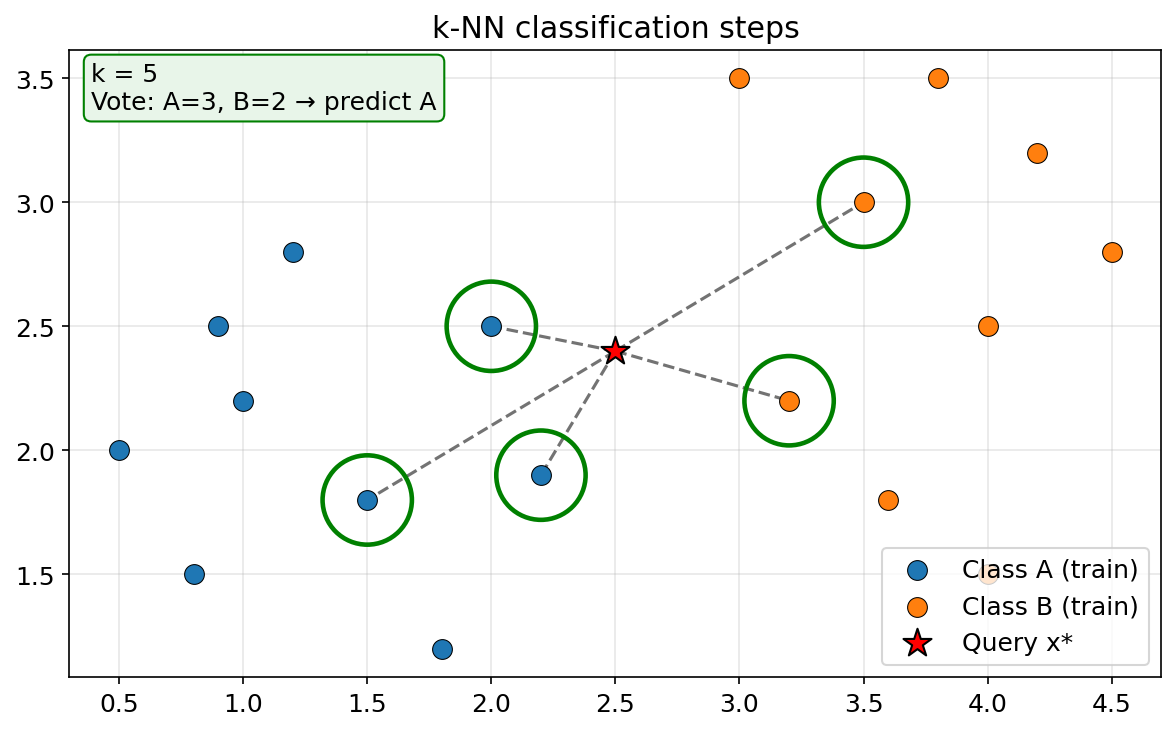

In [3]:
show_png("knn_classify_steps.png", width=720)


### Manual walkthrough on a tiny set

We implement the steps ourselves (no sklearn yet) so every line is visible.


In [4]:
# Toy 2D training set
X_train = np.array([
    [1.0, 2.2], [1.5, 1.8], [0.8, 1.5], [2.0, 2.5], [1.2, 2.8],  # class 0
    [3.5, 3.0], [4.0, 2.5], [3.2, 2.2], [3.8, 3.5], [4.2, 3.2],  # class 1
])
y_train = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])
x_query = np.array([2.5, 2.4])
k = 5

dists = np.sqrt(((X_train - x_query) ** 2).sum(axis=1))
nn_idx = np.argsort(dists)[:k]
nn_labels = y_train[nn_idx]
values, counts = np.unique(nn_labels, return_counts=True)
pred = values[np.argmax(counts)]

print("Distances:", np.round(dists, 3))
print("k-NN indices:", nn_idx, "labels:", nn_labels)
print("Vote counts:", dict(zip(values.tolist(), counts.tolist())))
print("Predicted class:", int(pred))


Distances: [1.513 1.166 1.924 0.51  1.36  1.166 1.503 0.728 1.703 1.879]
k-NN indices: [3 7 1 5 4] labels: [0 1 0 1 0]
Vote counts: {0: 3, 1: 2}
Predicted class: 0


In [18]:
x_query

array([2.5, 2.4])

In [20]:
X_train

array([[1. , 2.2],
       [1.5, 1.8],
       [0.8, 1.5],
       [2. , 2.5],
       [1.2, 2.8],
       [3.5, 3. ],
       [4. , 2.5],
       [3.2, 2.2],
       [3.8, 3.5],
       [4.2, 3.2]])

In [24]:
(X_train - x_query) ** 2

array([[2.25, 0.04],
       [1.  , 0.36],
       [2.89, 0.81],
       [0.25, 0.01],
       [1.69, 0.16],
       [1.  , 0.36],
       [2.25, 0.01],
       [0.49, 0.04],
       [1.69, 1.21],
       [2.89, 0.64]])

In [25]:
np.sum((X_train - x_query) ** 2, axis=1)

array([2.29, 1.36, 3.7 , 0.26, 1.85, 1.36, 2.26, 0.53, 2.9 , 3.53])

In [27]:
y_train[[3, 7, 1, 5, 4]] # majority: 0

array([0, 1, 0, 1, 0])

In [5]:
# Same idea for regression: average of neighbour targets
y_reg = np.array([2.0, 2.2, 1.8, 2.5, 2.4, 5.0, 5.2, 4.8, 5.5, 5.1])
pred_reg = y_reg[nn_idx].mean()
print("Neighbour targets:", y_reg[nn_idx])
print("Regression prediction (mean):", round(pred_reg, 3))


Neighbour targets: [2.5 4.8 2.2 5.  2.4]
Regression prediction (mean): 3.38


### Self-check A

If k=1 and the single nearest label is 1, what is the classification prediction?  
If those same k neighbours have targets [5, 5, 4, 6, 5], what is the regression mean?


## 2. Distance metrics: Euclidean, Manhattan, Minkowski

- **Euclidean (p=2):** straight-line length — default intuition.
- **Manhattan (p=1):** sum of absolute axis moves — city blocks.
- **Minkowski:** dₚ(x,z) = (Σᵢ |xᵢ − zᵢ|ᵖ)^(1/p) covers both.

Cosine similarity uses **angle**, not default tabular k-NN distance — optional awareness only.


### Figure — same two points, both paths


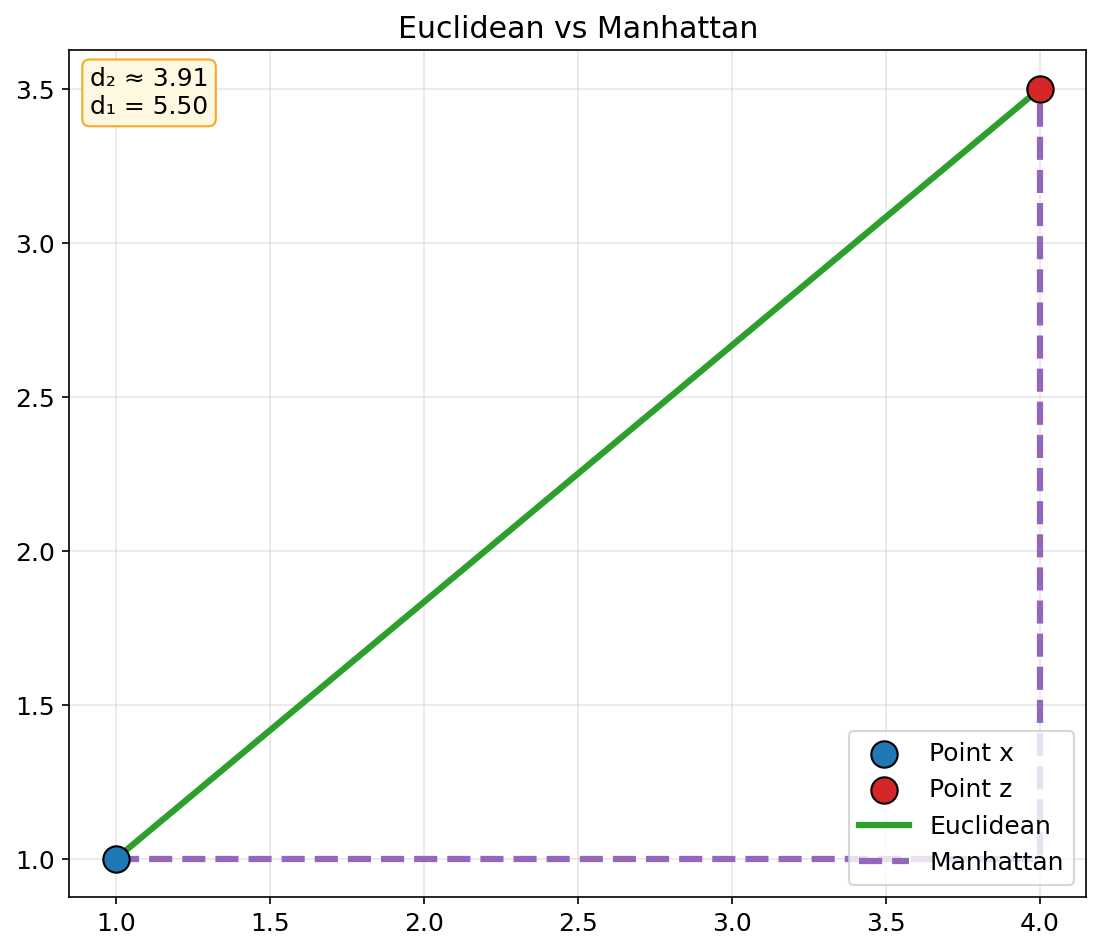

In [6]:
show_png("euclidean_vs_manhattan.png", width=700)


In [7]:
x = np.array([1.0, 1.0])
z = np.array([4.0, 3.5])
d2 = np.sqrt(((x - z) ** 2).sum())
d1 = np.abs(x - z).sum()
print(f"Euclidean d2 = {d2:.4f}")
print(f"Manhattan d1 = {d1:.4f}")
print("Check: Manhattan >= Euclidean?", d1 >= d2)

def minkowski(a, b, p):
    return (np.abs(a - b) ** p).sum() ** (1 / p)

print("Minkowski p=1:", minkowski(x, z, 1))
print("Minkowski p=2:", minkowski(x, z, 2))


Euclidean d2 = 3.9051
Manhattan d1 = 5.5000
Check: Manhattan >= Euclidean? True
Minkowski p=1: 5.5
Minkowski p=2: 3.905124837953327


### Why scaling matters

If one feature is in thousands and another in tens, Euclidean distance is dominated by the large-scale feature. **Always scale** (e.g. StandardScaler) before classic k-NN on mixed units.


### Figure — before / after scaling


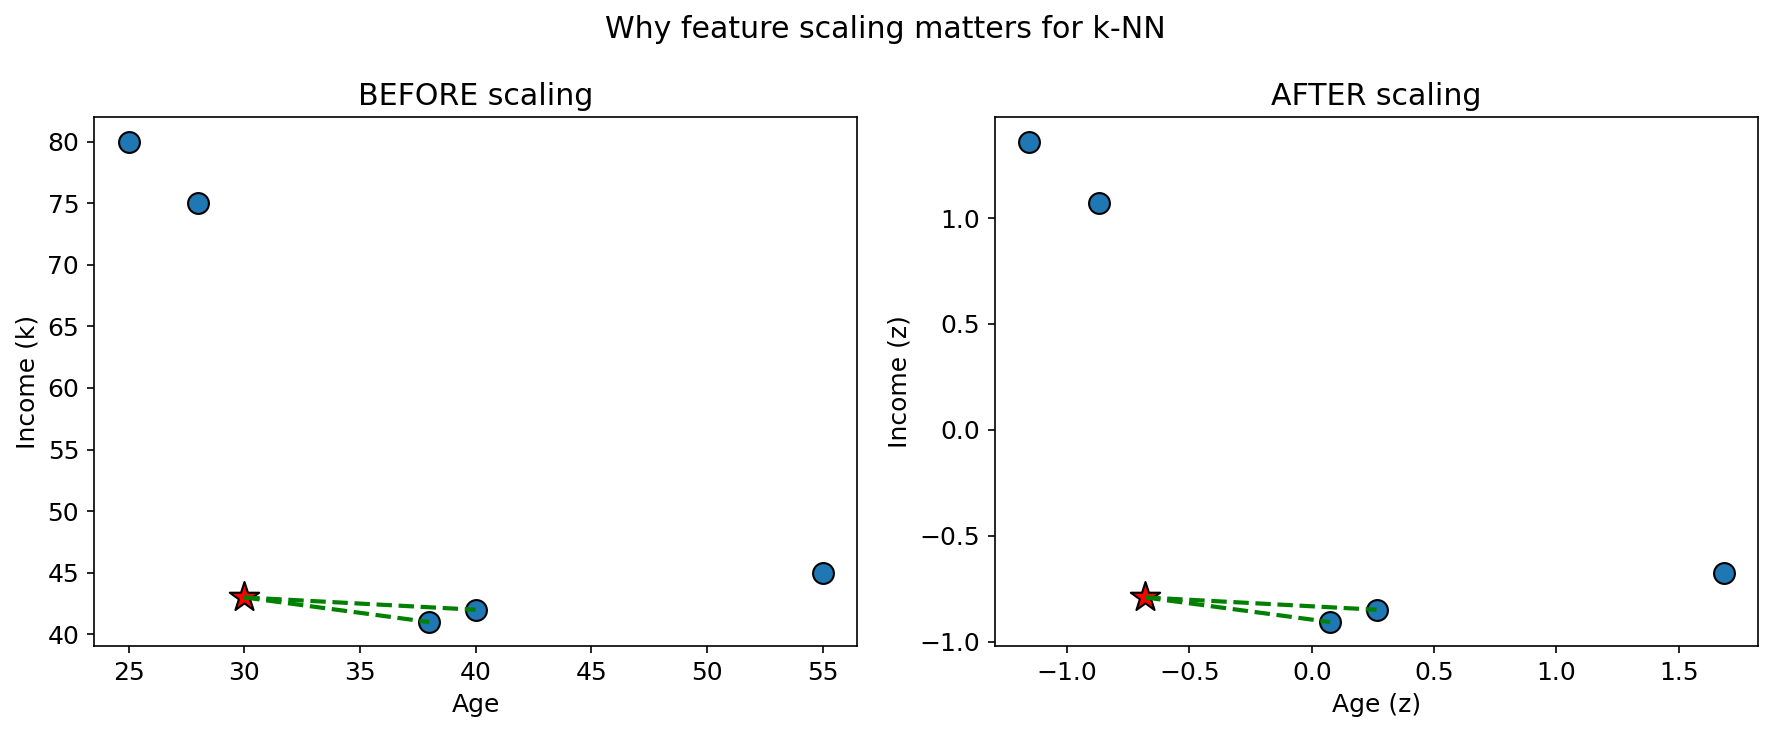

In [8]:
show_png("scaling_matters.png", width=900)


In [9]:
# Reproduce the scaling lesson numerically
train = np.array([
    [25, 80000],
    [40, 42000],
    [38, 41000],
    [55, 45000],
    [28, 75000],
])
q = np.array([30.0, 43000.0])

d_raw = np.linalg.norm(train - q, axis=1)
print("Raw distances:", np.round(d_raw, 1))
print("2-NN indices (raw):", np.argsort(d_raw)[:2])

mu, sd = train.mean(0), train.std(0)
train_s = (train - mu) / sd
q_s = (q - mu) / sd
d_s = np.linalg.norm(train_s - q_s, axis=1)
print("Scaled distances:", np.round(d_s, 3))
print("2-NN indices (scaled):", np.argsort(d_s)[:2])


Raw distances: [37000.   1000.   2000.   2000.2 32000. ]
2-NN indices (raw): [1 2]
Scaled distances: [2.204 0.948 0.766 2.368 1.871]
2-NN indices (scaled): [2 1]


### Self-check B

Which Minkowski **p** is Euclidean? Which is Manhattan?  
True/False: cosine similarity is the default distance inside classic tabular k-NN.


## 3. Choosing k and bias–variance

- **Small k** (e.g. 1): flexible boundary, **low bias / high variance** → can **overfit** noise.
- **Large k**: smoother regions, **higher bias / lower variance** → can **underfit**.
- **Odd k** in binary classification helps avoid 50–50 vote ties.
- Pick k with **validation** or **cross-validation** (same idea as choosing regularization strength).


### Figure — decision boundaries for k=1, 5, 25


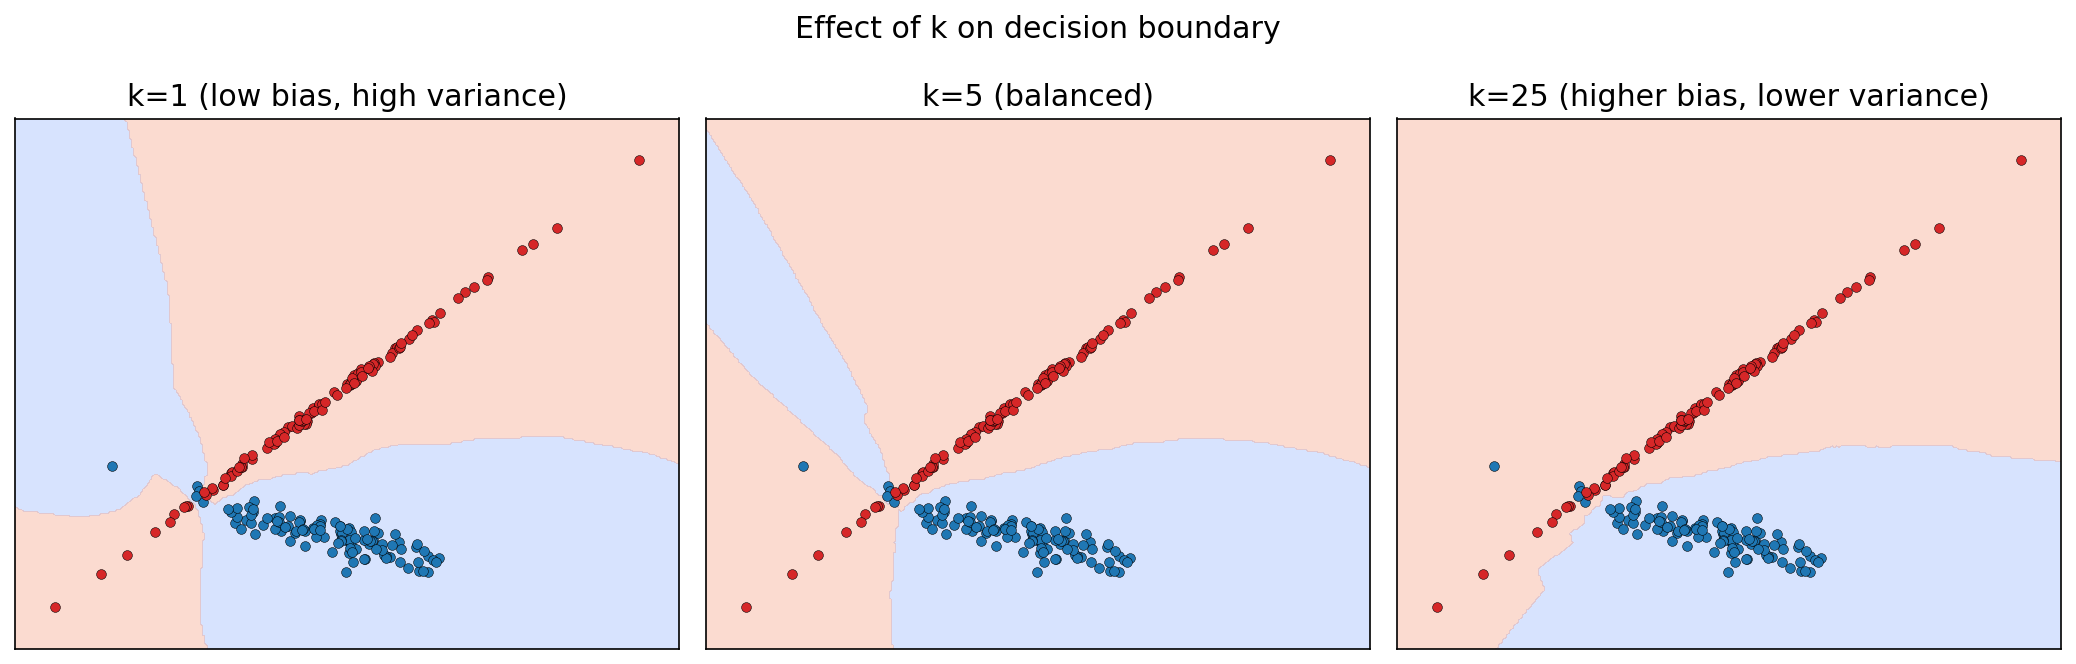

In [10]:
show_png("k_bias_variance_boundaries.png", width=960)


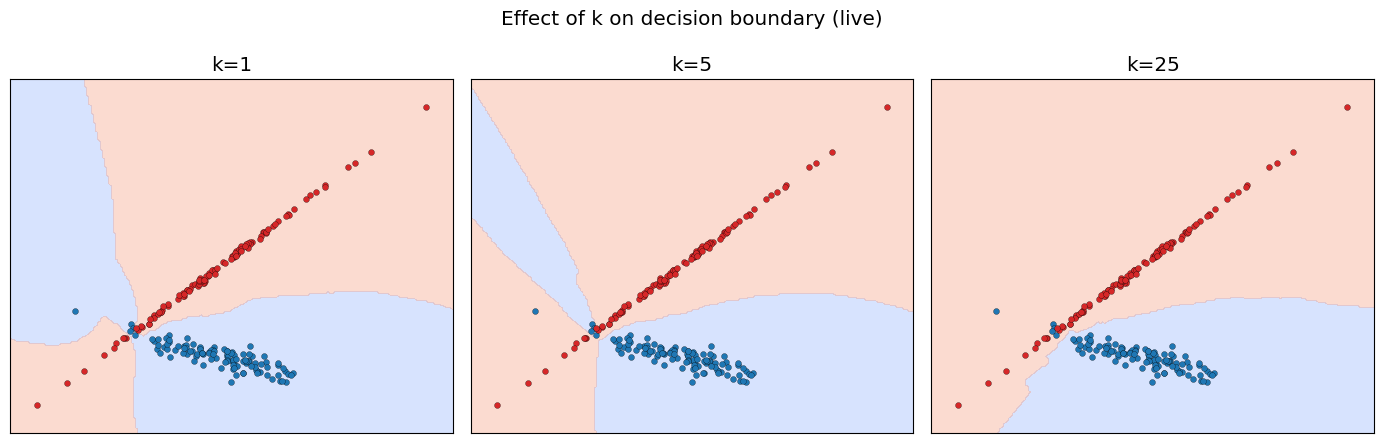

In [11]:
# Interactive demo: boundaries for k=1,5,25 (PNG already written in section 0b)
X, y = make_classification(
    n_samples=220, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=1.0, random_state=42,
)
X = StandardScaler().fit_transform(X)
ks = [1, 5, 25]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200),
    np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 200),
)
grid = np.c_[xx.ravel(), yy.ravel()]
titles = ["k=1", "k=5", "k=25"]
for ax, k, title in zip(axes, ks, titles):
    clf = KNeighborsClassifier(n_neighbors=k).fit(X, y)
    Z = clf.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap="coolwarm", levels=1)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c="#1f77b4", s=18, edgecolors="k", linewidths=0.2)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="#d62728", s=18, edgecolors="k", linewidths=0.2)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Effect of k on decision boundary (live)")
fig.tight_layout()
plt.show()


In [12]:
# Conceptual model selection: CV over k
X_cv, y_cv = make_classification(
    n_samples=400, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=1.1, random_state=0,
)
pipe_scores = {}
for k in [1, 3, 5, 11, 25, 51]:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k)),
    ])
    scores = cross_val_score(pipe, X_cv, y_cv, cv=5)
    pipe_scores[k] = (scores.mean(), scores.std())
    print(f"k={k:2d}  CV accuracy = {scores.mean():.3f} ± {scores.std():.3f}")

best_k = max(pipe_scores, key=lambda kk: pipe_scores[kk][0])
print("Best k by mean CV accuracy:", best_k)


k= 1  CV accuracy = 0.838 ± 0.045
k= 3  CV accuracy = 0.868 ± 0.045
k= 5  CV accuracy = 0.868 ± 0.038
k=11  CV accuracy = 0.890 ± 0.031
k=25  CV accuracy = 0.895 ± 0.036
k=51  CV accuracy = 0.903 ± 0.037
Best k by mean CV accuracy: 51


### Self-check C

Fill in: k=1 → ____ variance; large k → ____ bias.  
Why prefer odd k for binary majority vote?


## 4. Curse of dimensionality (distance concentration)

In high **d**, volume grows fast and distances between random points **concentrate**.
The relative gap (max − min) / mean often **shrinks** → nearest ≈ farthest → k-NN weakens.

**Mitigations:** scale features; use fewer informative features / reduce dimension; gather more data; consider other models when d ≫ n.


### Figure — (max−min)/mean vs dimension


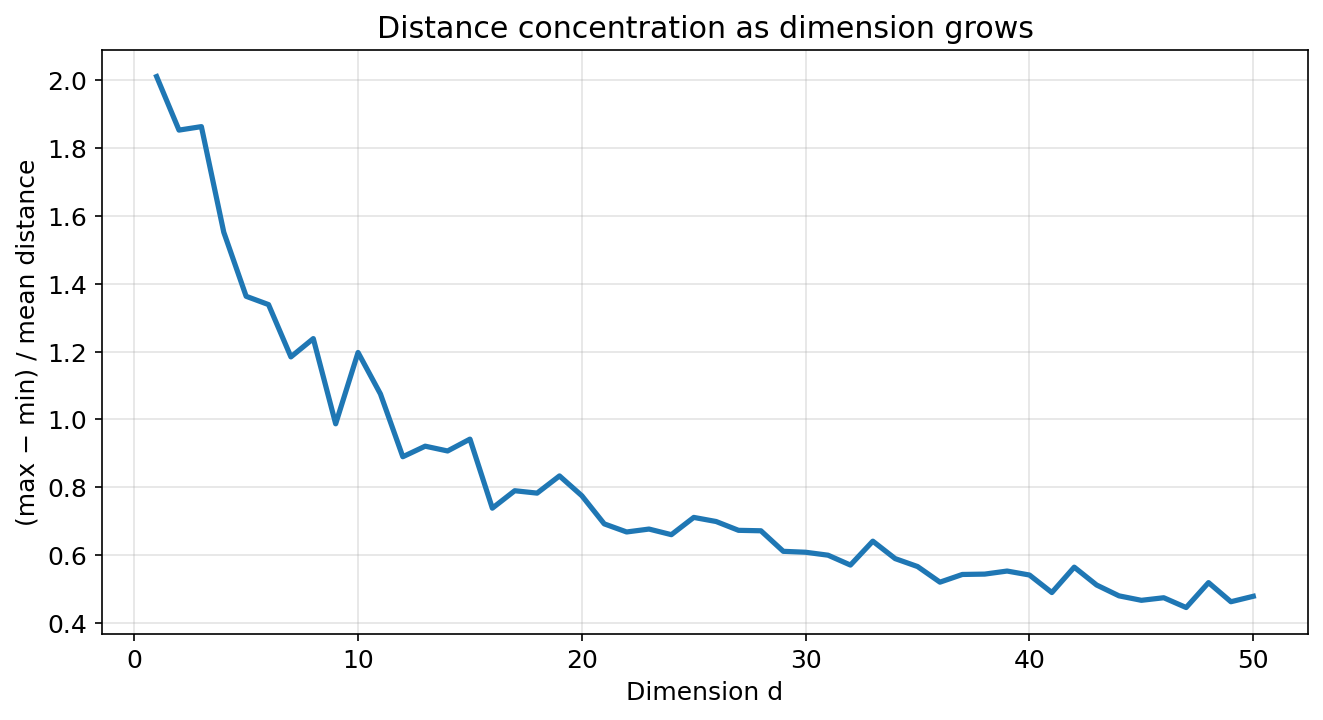

In [13]:
show_png("curse_concentration.png", width=820)


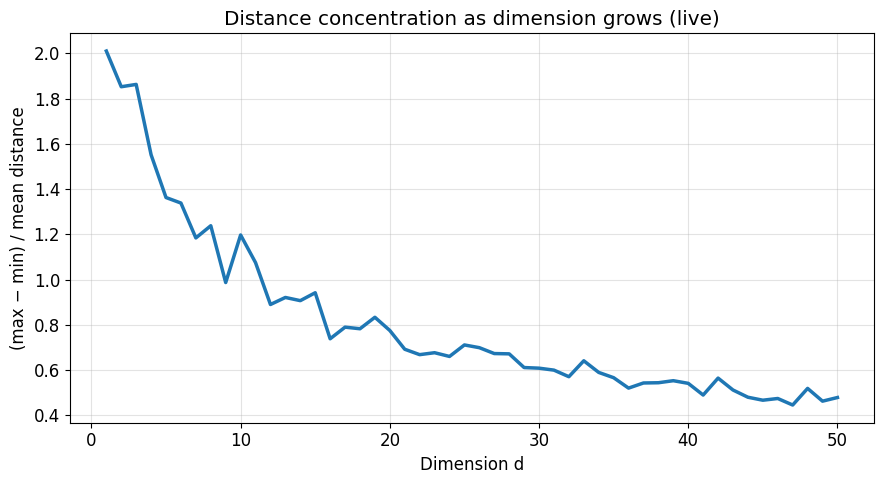

ratio at d=2: 1.852 | at d=40: 0.542


In [14]:
# Interactive demo: concentration curve (PNG already written in section 0b)
rng = np.random.default_rng(0)
dims = list(range(1, 51))
ratios = []
n_pts = 500
for d in dims:
    data = rng.random((n_pts, d))
    q = rng.random(d)
    dists = np.linalg.norm(data - q, axis=1)
    ratios.append((dists.max() - dists.min()) / dists.mean())
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(dims, ratios, lw=2.5)
ax.set_xlabel("Dimension d")
ax.set_ylabel("(max − min) / mean distance")
ax.set_title("Distance concentration as dimension grows (live)")
ax.grid(True, alpha=0.35)
fig.tight_layout()
plt.show()
print("ratio at d=2:", round(ratios[1], 3), "| at d=40:", round(ratios[39], 3))


### Self-check D

As dimension increases, does (max−min)/mean typically go **up** or **down**?  
Name two practical mitigations for k-NN in high dimensions.


## 5. sklearn end-to-end mini demo

Pipeline: scale → k-NN. Compare Euclidean vs Manhattan briefly; classify and regress.


In [15]:
X, y = make_classification(
    n_samples=300, n_features=4, n_informative=3, n_redundant=0,
    n_clusters_per_class=1, random_state=7,
)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=7)

for metric, p in [("euclidean", 2), ("manhattan", 1)]:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=5, metric="minkowski", p=p)),
    ])
    pipe.fit(X_tr, y_tr)
    acc = pipe.score(X_te, y_te)
    print(f"{metric:10s} (p={p}): test accuracy = {acc:.3f}")


euclidean  (p=2): test accuracy = 1.000
manhattan  (p=1): test accuracy = 1.000


In [16]:
# Regression flavour
Xr, yr = make_regression(n_samples=250, n_features=3, noise=15.0, random_state=3)
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.25, random_state=3)
reg = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=7)),
])
reg.fit(Xr_tr, yr_tr)
r2 = reg.score(Xr_te, yr_te)
print(f"KNeighborsRegressor R^2 on test: {r2:.3f}")


KNeighborsRegressor R^2 on test: 0.917


## 6. Unmarked quiz recap (reason them out)

**Q1.** During classic k-NN “fit”, what mainly happens? (store data vs learn w)

**Q2.** Minkowski p for Euclidean? for Manhattan?

**Q3.** Why scale features before Euclidean k-NN on Age + Income?

**Q4.** Odd k in binary classification — main practical reason?

**Q5.** k=1 vs k=25: which has higher variance?

**Q6.** High-d distances: concentrate or spread out in relative contrast?


## 7. Recap

1. Predict by majority / average of **k** nearest training points.
2. Distances: Euclidean & Manhattan inside Minkowski; **scale** features.
3. Small k → flexible / high variance; large k → smooth / high bias; tune k with validation/CV.
4. High dimension → distance concentration → nearest is less special → mitigate with scale, fewer features, more data.

*End of CML9 full teaching notebook*
